# Filter Methods: Chi-Square Test for Categorical Feature Selection

![Chi Square Data](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8e/Chi-square_distributionPDF.png/600px-Chi-square_distributionPDF.png)

*Image: The Chi-Square distribution. As the degrees of freedom (k) increase, the distribution approaches a normal curve.* 

### 1. Clear Overview
The **Chi-Square ($\chi^2$) test** is a statistical filter method used to evaluate the association between two categorical variables. In feature engineering, it assesses whether a categorical feature and the target variable are independent. 

* **Significant Dependency:** The feature likely contains predictive signal.
* **Independent:** The feature is likely irrelevant and can be safely discarded.

### 2. Theory: Intuition Behind the Test
The test operates by comparing the **Observed frequency** (the counts we actually see in the data) against the **Expected frequency** (what we would expect to see if the feature and target were purely independent).

**The Logic:**
* If observed counts align closely with expected counts, the variables are likely **independent** (the feature adds no value).
* If there is a large discrepancy between observed and expected counts, the variables are **dependent** (the feature is likely informative).

**Mathematical Formulation:**
$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

Where:
* **O** = Observed frequency
* **E** = Expected frequency

*A higher $\chi^2$ score indicates a stronger deviation from independence, meaning the feature and target are more strongly associated.*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import OrdinalEncoder

sns.set_theme(style="whitegrid")

### 3. Generating Synthetic Categorical Data
Let's create a dataset with a mix of highly predictive categorical features and pure noise.

In [2]:
np.random.seed(42)
n_samples = 1500

# Target Variable: Churn (Binary)
y_churn = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])

# Predictive Feature 1: Subscription Tier (Highly correlated with Churn)
# If churn=1, more likely to be 'Basic'. If churn=0, more likely to be 'Premium'
tier = np.where(y_churn == 1, 
                np.random.choice(['Basic', 'Standard', 'Premium'], size=n_samples, p=[0.7, 0.2, 0.1]),
                np.random.choice(['Basic', 'Standard', 'Premium'], size=n_samples, p=[0.2, 0.3, 0.5]))

# Predictive Feature 2: Support Tickets Opened (Correlated)
tickets = np.where(y_churn == 1,
                   np.random.choice(['High', 'Low'], size=n_samples, p=[0.8, 0.2]),
                   np.random.choice(['High', 'Low'], size=n_samples, p=[0.3, 0.7]))

# Noise Feature: App Theme Color (Purely random, independent of Churn)
theme_color = np.random.choice(['Light', 'Dark', 'System'], size=n_samples)

df = pd.DataFrame({
    'Subscription_Tier': tier,
    'Support_Tickets': tickets,
    'App_Theme_Color': theme_color,
    'Churn': y_churn
})

display(df.head())

,Subscription_Tier,Support_Tickets,App_Theme_Color,Churn
0,Premium,Low,Dark,0
1,Basic,High,Light,1
2,Basic,High,Light,1
3,Premium,Low,Light,0
4,Premium,High,Light,0


### 4. Deep Dive: Observed vs Expected (Manual Contingency Table)
Before blindly using Scikit-Learn, let's look at the underlying math using `scipy.stats.chi2_contingency` on our highly predictive feature (`Subscription_Tier`).

In [3]:
# Create a cross-tabulation (contingency table) of Observed Frequencies
observed_crosstab = pd.crosstab(df['Subscription_Tier'], df['Churn'])
print("--- OBSERVED FREQUENCIES ---")
display(observed_crosstab)

# Run the statistical test
chi2_stat, p_val, dof, expected_freq = chi2_contingency(observed_crosstab)

print("\n--- EXPECTED FREQUENCIES (If strictly independent) ---")
expected_df = pd.DataFrame(expected_freq, index=observed_crosstab.index, columns=observed_crosstab.columns)
display(expected_df.round(1))

print(f"\nChi-Square Statistic: {chi2_stat:.2f}")
print(f"P-Value: {p_val:.2e}")
print("Interpretation: The massive difference between Observed and Expected yields a high Chi-Square score and a tiny p-value. This feature is highly predictive!")

--- OBSERVED FREQUENCIES ---


Churn,0,1
Subscription_Tier,,
Basic,216,306
Premium,530,46
Standard,305,97



--- EXPECTED FREQUENCIES (If strictly independent) ---


Churn,0,1
Subscription_Tier,,
Basic,365.7,156.3
Premium,403.6,172.4
Standard,281.7,120.3



Chi-Square Statistic: 343.57
P-Value: 2.48e-75
Interpretation: The massive difference between Observed and Expected yields a high Chi-Square score and a tiny p-value. This feature is highly predictive!


### 5. Automated Feature Selection with Scikit-Learn
Now we apply `SelectKBest` with the `chi2` scoring function to automate this across all features. 

**Note on Implementation:** Scikit-Learn's `chi2` expects non-negative numerical values, so we must first Ordinal-Encode our string categories.

In [4]:
# Separate Features and Target
X_categorical = df.drop(columns=['Churn'])
y = df['Churn']

# Encode string labels into numerical integer formats required by Scikit-Learn
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X_categorical)
X_encoded = pd.DataFrame(X_encoded, columns=X_categorical.columns)

# Initialize and fit SelectKBest
# We ask it to evaluate all features so we can plot the scores
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_encoded, y)

# Retrieve the scores for each feature
feature_scores = pd.DataFrame({
    'Feature': X_categorical.columns, 
    'Chi2_Score': selector.scores_,
    'P_Value': selector.pvalues_
})

# Sort for better visualization
feature_scores = feature_scores.sort_values(by='Chi2_Score', ascending=False)
display(feature_scores)

,Feature,Chi2_Score,P_Value
1,Support_Tickets,141.858671,1.044200e-32
0,Subscription_Tier,103.501858,2.601500e-24
2,App_Theme_Color,0.186162,6.661302e-01


### 6. Visualization and Application Summary

C:\Users\balasubramanian.pg\AppData\Local\Temp\ipykernel_30376\3688808360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Chi2_Score', y='Feature', data=feature_scores, palette='magma')


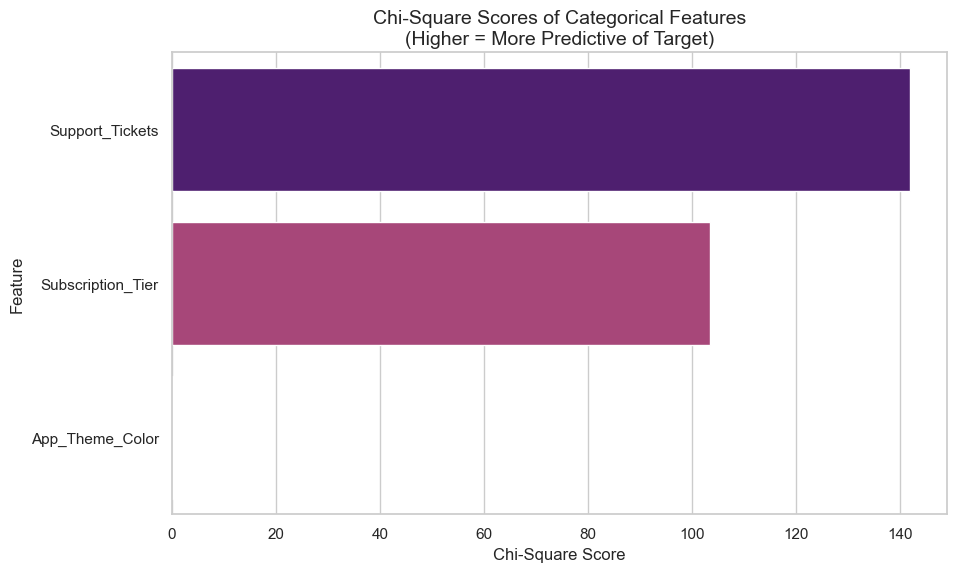


--- ACTIONABLE INSIGHT ---
Notice how 'App_Theme_Color' has a near-zero score. If we set k=2 in SelectKBest, 
this irrelevant noise feature would be successfully filtered out before model training.


In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Chi2_Score', y='Feature', data=feature_scores, palette='magma')
plt.title("Chi-Square Scores of Categorical Features\n(Higher = More Predictive of Target)", fontsize=14)
plt.xlabel("Chi-Square Score")
plt.ylabel("Feature")
plt.show()

print("\n--- ACTIONABLE INSIGHT ---")
print("Notice how 'App_Theme_Color' has a near-zero score. If we set k=2 in SelectKBest, ")
print("this irrelevant noise feature would be successfully filtered out before model training.")